# Cross-Dataset Results
Compares **SFT baseline**, **EWL**, and **EWL (no grad proxy)** across four FGVC datasets.

All conditions: rank=4, α=0.9, τ=1.0 · Seeds {11, 22, 33} · mean ± std.

In [17]:
import re, json, numpy as np, pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

plt.rcParams.update({
    "figure.dpi": 130,
    "font.family": "sans-serif",
    "font.size": 11,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "grid.linestyle": "--",
    "legend.framealpha": 0.9,
    "legend.fontsize": 9,
})

C = {
    "baseline":     "#D6604D",   # muted red
    "ewl":          "#2166AC",   # steel blue
    "ewl_no_proxy": "#4DAC26",   # muted green
}

BASE_DIR = Path("../outputs/vision/all_datasets")
DATASETS  = ["aircraft", "cub200", "stanford_dogs"]#, "food101"]
SEEDS     = [11, 22, 33]
CONDITIONS = ["baseline", "ewl", "ewl_no_proxy"]

_DIR_RE = re.compile(r"^(baseline|ewl_no_proxy|ewl)_s(\d+)$")

def load_all(base=BASE_DIR, seeds=SEEDS):
    rows = []
    for ds in DATASETS:
        ds_dir = base / ds
        if not ds_dir.exists():
            continue
        for d in sorted(ds_dir.iterdir()):
            if not d.is_dir(): continue
            m = _DIR_RE.match(d.name)
            if not m: continue
            cond, seed = m[1], int(m[2])
            if seed not in seeds: continue
            jsons = sorted(d.glob("results_*.json"))
            if not jsons: continue
            with open(jsons[-1]) as f:
                payload = json.load(f)
            rows.append({
                "dataset":   ds,
                "condition": cond,
                "seed":      seed,
                "test_acc":  payload.get("test_acc"),
                "test_f1":   payload.get("test_f1"),
                "test_loss": payload.get("test_loss"),
                "history":   payload.get("history", []),
            })
    df = pd.DataFrame(rows)
    print(f"Loaded {len(df)} runs across {df['dataset'].nunique()} datasets")
    return df

df = load_all()
df.drop(columns="history").sort_values(["dataset","condition","seed"])

Loaded 27 runs across 3 datasets


,dataset,condition,seed,test_acc,test_f1,test_loss
0,aircraft,baseline,11,0.582958,0.582287,1.510465
1,aircraft,baseline,22,0.591359,0.592108,1.500386
2,aircraft,baseline,33,0.594359,0.593704,1.485645
6,aircraft,ewl,11,0.582658,0.582343,1.560941
7,aircraft,ewl,22,0.593459,0.593950,1.544171
8,aircraft,ewl,33,0.596160,0.596465,1.528144
3,aircraft,ewl_no_proxy,11,0.521752,0.522305,2.147176
4,aircraft,ewl_no_proxy,22,0.519352,0.514336,2.127538
5,aircraft,ewl_no_proxy,33,0.517252,0.516926,2.057899
9,cub200,baseline,11,0.864860,0.864030,0.563966


## Summary Table
mean ± std test accuracy across seeds.

In [18]:
COND_LABELS = {
    "baseline":     "SFT baseline",
    "ewl":          "EWL",
    "ewl_no_proxy": "EWL (no proxy)",
}
DS_LABELS = {
    "aircraft":      "FGVC-Aircraft",
    "cub200":        "CUB-200",
    "stanford_dogs": "Stanford Dogs",
    # "food101":       "Food-101",
}

table_rows = []
for ds in DATASETS:
    row = {"Dataset": DS_LABELS.get(ds, ds)}
    for cond in CONDITIONS:
        vals = df[(df.dataset == ds) & (df.condition == cond)]["test_acc"].dropna()
        if len(vals):
            row[COND_LABELS[cond]] = f"{vals.mean():.4f} ± {vals.std():.4f}"
            row[f"_n_{cond}"] = len(vals)
        else:
            row[COND_LABELS[cond]] = "—"
            row[f"_n_{cond}"] = 0
    # Delta columns
    for cond in ["ewl", "ewl_no_proxy"]:
        base_vals = df[(df.dataset == ds) & (df.condition == "baseline")]["test_acc"].dropna()
        cond_vals = df[(df.dataset == ds) & (df.condition == cond)]["test_acc"].dropna()
        if len(base_vals) and len(cond_vals):
            delta = cond_vals.mean() - base_vals.mean()
            row[f"Δ {COND_LABELS[cond]}"] = f"{delta:+.4f}"
        else:
            row[f"Δ {COND_LABELS[cond]}"] = "—"
    table_rows.append(row)

display_cols = ["Dataset"] + list(COND_LABELS.values()) + [f"Δ {v}" for v in list(COND_LABELS.values())[1:]]
summary = pd.DataFrame(table_rows)[display_cols].set_index("Dataset")

# Highlight: colour positive deltas
def highlight_delta(val):
    if isinstance(val, str) and val.startswith("+"):
        return "color: #2166AC; font-weight: bold"
    if isinstance(val, str) and val.startswith("-"):
        return "color: #D6604D"
    return ""

summary.style.applymap(highlight_delta, subset=[c for c in summary.columns if c.startswith("Δ")])

/tmp/ipykernel_1279879/644984895.py:46: FutureWarning: Styler.applymap has been deprecated. Use Styler.map instead.
  summary.style.applymap(highlight_delta, subset=[c for c in summary.columns if c.startswith("Δ")])


,SFT baseline,EWL,EWL (no proxy),Δ EWL,Δ EWL (no proxy)
Dataset,,,,,
FGVC-Aircraft,0.5896 ± 0.0059,0.5908 ± 0.0071,0.5195 ± 0.0023,+0.0012,-0.0701
CUB-200,0.8626 ± 0.0043,0.8630 ± 0.0052,0.8555 ± 0.0046,+0.0004,-0.0071
Stanford Dogs,0.8946 ± 0.0009,0.8946 ± 0.0005,0.8902 ± 0.0028,+0.0000,-0.0044


## Figure — Test accuracy comparison across datasets

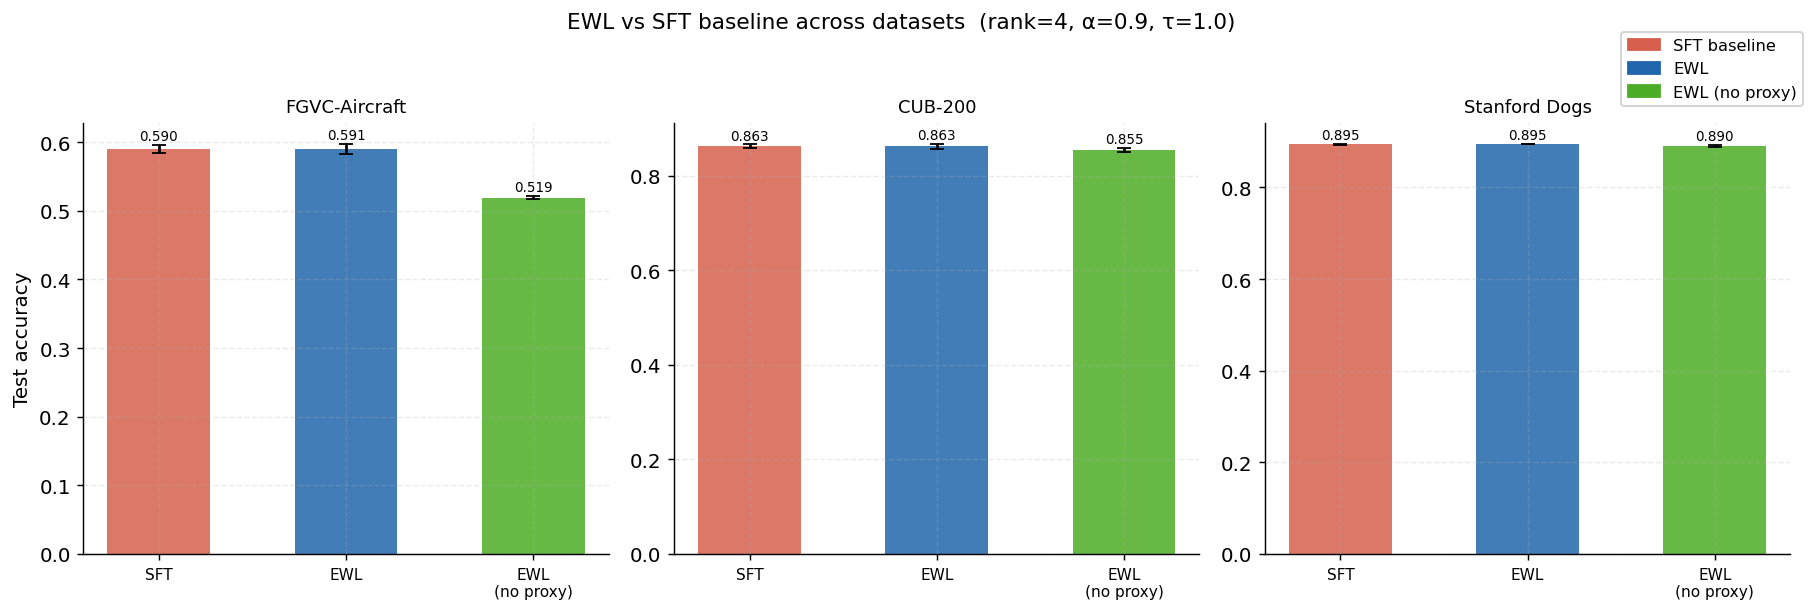

In [19]:
fig, axes = plt.subplots(1, len(DATASETS), figsize=(14, 4.5), sharey=False)

xs = np.arange(len(CONDITIONS))
w  = 0.55
labels = [COND_LABELS[c] for c in CONDITIONS]

for ax, ds in zip(axes, DATASETS):
    means, stds = [], []
    for cond in CONDITIONS:
        vals = df[(df.dataset == ds) & (df.condition == cond)]["test_acc"].dropna()
        means.append(vals.mean() if len(vals) else np.nan)
        stds.append(vals.std()  if len(vals) else 0.0)

    bars = ax.bar(xs, means, w, yerr=stds, capsize=4,
                  color=[C[c] for c in CONDITIONS], alpha=0.85)
    for bar, mu, sd in zip(bars, means, stds):
        if not np.isnan(mu):
            ax.text(bar.get_x() + bar.get_width()/2, mu + sd + 0.003,
                    f"{mu:.3f}", ha="center", va="bottom", fontsize=7.5)

    ax.set_xticks(xs)
    ax.set_xticklabels(["SFT", "EWL", "EWL\n(no proxy)"], fontsize=8.5)
    ax.set_title(DS_LABELS.get(ds, ds), fontsize=10)
    ax.set_ylabel("Test accuracy" if ds == DATASETS[0] else "")

# Shared legend
from matplotlib.patches import Patch
legend_el = [Patch(color=C[c], label=COND_LABELS[c]) for c in CONDITIONS]
fig.legend(handles=legend_el, loc="upper right", bbox_to_anchor=(1.0, 1.02), fontsize=9)

plt.suptitle("EWL vs SFT baseline across datasets  (rank=4, α=0.9, τ=1.0)",
             fontsize=12, y=1.04)
plt.tight_layout()
plt.savefig("fig_all_datasets.pdf", bbox_inches="tight")
plt.show()

## Figure — Learning curves (best config per dataset)

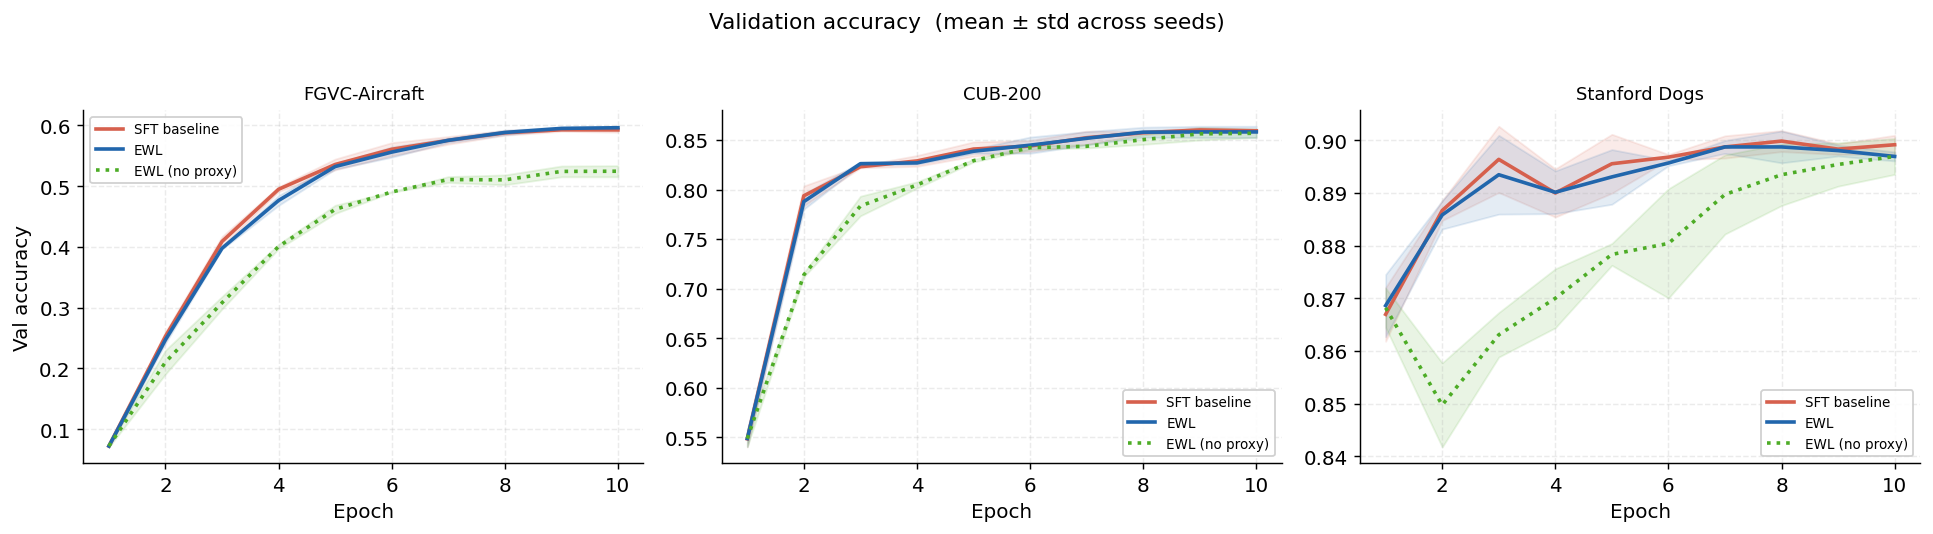

In [20]:
def get_curves(subset, metric="val_acc"):
    series = []
    for _, row in subset.iterrows():
        vals = [ep[metric] for ep in row["history"] if ep.get(metric) is not None]
        if vals: series.append(vals)
    if not series: return [], [], []
    min_len = min(len(s) for s in series)
    arr = np.array([s[:min_len] for s in series])
    return np.arange(1, min_len + 1), arr.mean(0), arr.std(0)

fig, axes = plt.subplots(1, len(DATASETS), figsize=(15, 4), sharey=False)

for ax, ds in zip(axes, DATASETS):
    for cond in CONDITIONS:
        sub = df[(df.dataset == ds) & (df.condition == cond)]
        ep, mu, sigma = get_curves(sub, "val_acc")
        if len(ep) == 0: continue
        ax.plot(ep, mu, color=C[cond], lw=2,
                ls="-" if cond != "ewl_no_proxy" else ":",
                label=COND_LABELS[cond])
        ax.fill_between(ep, mu - sigma, mu + sigma, color=C[cond], alpha=0.12)
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Val accuracy" if ds == DATASETS[0] else "")
    ax.set_title(DS_LABELS.get(ds, ds), fontsize=10)
    ax.legend(fontsize=7.5)

plt.suptitle("Validation accuracy  (mean ± std across seeds)", fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig("fig_all_datasets_curves.pdf", bbox_inches="tight")
plt.show()